# Dataset Preparation Summary

### Included Datasets
- ✅ **ACRIMA Dataset**
- ✅ **ORIGA Dataset**

### Excluded Dataset
- ❌ **Fundus Dataset**

## Reason for Exclusion

The **Fundus** dataset was compared with the **ORIGA** dataset using **MD5 hashing**. The comparison showed that **all 650 Fundus images were exact duplicates of images in the ORIGA dataset**.

To prevent:
- Data leakage
- Duplicate samples during training
- Biased model evaluation

the **Fundus dataset was excluded** from the final merged dataset.

## Final Dataset Statistics

| Class | Number of Images |
|--------|-----------------:|
| Normal | 791 |
| Glaucoma | 564 |
| **Total** | **1355** |

# Cell 1 : Kaggle Setup

In [1]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

# Cell 2 : Download Dataset from Kaggle

In [2]:
!kaggle datasets download -d sshikamaru/glaucoma-detection

Dataset URL: https://www.kaggle.com/datasets/sshikamaru/glaucoma-detection
License(s): CC0-1.0
100% 402M/402M [00:06<00:00, 68.6MB/s]



# Cell 3 : Extract Dataset ZIP

In [3]:
import zipfile
zip_ref = zipfile.ZipFile('/content/glaucoma-detection.zip')
zip_ref.extractall('/content')
zip_ref.close()

# Cell 4 : Install ImageHash Library

In [4]:
!pip install ImageHash -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 9.4 MB/s eta 0:00:00


# Cell 5 : Import Required Libraries

In [5]:
import os
import shutil
from pathlib import Path
from collections import Counter

import cv2
import numpy as np
import pandas as pd

from PIL import Image
import imagehash

from tqdm import tqdm

# Cell 6 : Define Dataset Root Paths

In [7]:
# ===============================
# Dataset Root Path
# ===============================

ROOT = "/content/"

ACRIMA_PATH = os.path.join(ROOT, "ACRIMA", "Images")

ORIGA_PATH = os.path.join(ROOT, "ORIGA", "ORIGA", "Images")

FUNDUS_PATH = os.path.join(
    ROOT,
    "Fundus_Train_Val_Data",
    "Fundus_Scanes_Sorted"
)

# Cell 7 : Create Working Dataset Directories

In [8]:
# ============================================
# Create Working Dataset
# ============================================

WORKING_DIR = "/content/Working_Dataset"

NORMAL_DIR = os.path.join(WORKING_DIR, "Normal")
GLAUCOMA_DIR = os.path.join(WORKING_DIR, "Glaucoma")

os.makedirs(NORMAL_DIR, exist_ok=True)
os.makedirs(GLAUCOMA_DIR, exist_ok=True)

print("Working Directory Created Successfully")

Working Directory Created Successfully


# Cell 8 : Define Image Counting Function

In [10]:
import os

def count_images(directory):
    """Counts the number of image files in a given directory."""
    if not os.path.exists(directory):
        return 0

    # Supported image extensions
    valid_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff')

    return sum(
        1 for file_name in os.listdir(directory)
        if file_name.lower().endswith(valid_extensions)
    )

# Cell 9 : Dataset Image Count Summary

In [11]:
train_positive = count_images(os.path.join(FUNDUS_PATH, "Train", "Glaucoma_Positive"))
train_negative = count_images(os.path.join(FUNDUS_PATH, "Train", "Glaucoma_Negative"))

val_positive = count_images(os.path.join(FUNDUS_PATH, "Validation", "Glaucoma_Positive"))
val_negative = count_images(os.path.join(FUNDUS_PATH, "Validation", "Glaucoma_Negative"))

print("=" * 50)

print("ACRIMA :", count_images(ACRIMA_PATH))
print("ORIGA  :", count_images(ORIGA_PATH))

print("\nFundus Dataset")
print("----------------")
print("Train Positive :", train_positive)
print("Train Negative :", train_negative)
print("Validation Positive :", val_positive)
print("Validation Negative :", val_negative)

print("\nTotal Fundus :", train_positive + train_negative + val_positive + val_negative)

print("=" * 50)

ACRIMA : 705
ORIGA  : 650

Fundus Dataset
----------------
Train Positive : 134
Train Negative : 386
Validation Positive : 34
Validation Negative : 96

Total Fundus : 650


# Cell 10 : Preview ACRIMA Filenames

In [12]:
files = sorted(os.listdir(ACRIMA_PATH))

print("First 30 Images")
print("-"*50)

for f in files[:30]:
    print(f)

print("\nLast 30 Images")
print("-"*50)

for f in files[-30:]:
    print(f)

First 30 Images
--------------------------------------------------
Im001_ACRIMA.jpg
Im002_ACRIMA.jpg
Im003_ACRIMA.jpg
Im004_ACRIMA.jpg
Im005_ACRIMA.jpg
Im006_ACRIMA.jpg
Im007_ACRIMA.jpg
Im008_ACRIMA.jpg
Im009_ACRIMA.jpg
Im010_ACRIMA.jpg
Im011_ACRIMA.jpg
Im012_ACRIMA.jpg
Im013_ACRIMA.jpg
Im014_ACRIMA.jpg
Im015_ACRIMA.jpg
Im016_ACRIMA.jpg
Im017_ACRIMA.jpg
Im018_ACRIMA.jpg
Im019_ACRIMA.jpg
Im020_ACRIMA.jpg
Im021_ACRIMA.jpg
Im022_ACRIMA.jpg
Im023_ACRIMA.jpg
Im024_ACRIMA.jpg
Im025_ACRIMA.jpg
Im026_ACRIMA.jpg
Im027_ACRIMA.jpg
Im028_ACRIMA.jpg
Im029_ACRIMA.jpg
Im030_ACRIMA.jpg

Last 30 Images
--------------------------------------------------
Im676_g_ACRIMA.jpg
Im677_g_ACRIMA.jpg
Im678_g_ACRIMA.jpg
Im679_g_ACRIMA.jpg
Im680_g_ACRIMA.jpg
Im681_g_ACRIMA.jpg
Im682_g_ACRIMA.jpg
Im683_g_ACRIMA.jpg
Im684_g_ACRIMA.jpg
Im685_g_ACRIMA.jpg
Im686_g_ACRIMA.jpg
Im687_g_ACRIMA.jpg
Im688_g_ACRIMA.jpg
Im689_g_ACRIMA.jpg
Im690_g_ACRIMA.jpg
Im691_g_ACRIMA.jpg
Im692_g_ACRIMA.jpg
Im693_g_ACRIMA.jpg
Im694_g_ACRIMA

# Cell-6 : Merge ACRIMA

In [13]:
import shutil
from pathlib import Path

# Merge only ACRIMA Dataset

ac_normal = 0
ac_glaucoma = 0

files = sorted(os.listdir(ACRIMA_PATH))

for file in tqdm(files):

    src = os.path.join(ACRIMA_PATH, file)

    # Glaucoma Image
    if "_g_" in file.lower():

        new_name = f"ACRIMA_G_{ac_glaucoma+1:04d}.jpg"

        dst = os.path.join(GLAUCOMA_DIR, new_name)

        ac_glaucoma += 1

    # Normal Image
    else:

        new_name = f"ACRIMA_N_{ac_normal+1:04d}.jpg"

        dst = os.path.join(NORMAL_DIR, new_name)

        ac_normal += 1

    shutil.copy2(src, dst)

print("="*50)
print("ACRIMA Merge Completed")
print("Normal :", ac_normal)
print("Glaucoma :", ac_glaucoma)
print("="*50)

100%|██████████| 705/705 [00:00<00:00, 8549.90it/s]

ACRIMA Merge Completed
Normal : 309
Glaucoma : 396


# Cell 13 : Verify Merged Working Dataset

In [14]:
print("Normal Images :", len(os.listdir(NORMAL_DIR)))
print("Glaucoma Images :", len(os.listdir(GLAUCOMA_DIR)))

Normal Images : 309
Glaucoma Images : 396


# Cell 14 : Load Glaucoma CSV

In [15]:
df = pd.read_csv("glaucoma.csv")

# Cell 15 : Preview CSV Data

In [16]:
df.head()

,Filename,ExpCDR,Eye,Set,Glaucoma
0,001.jpg,0.7097,OD,A,0
1,002.jpg,0.6953,OS,A,0
2,003.jpg,0.9629,OS,A,0
3,004.jpg,0.7246,OD,A,0
4,005.jpg,0.6138,OS,A,0


# Cell 16 : Preview ORIGA Filenames

In [17]:
# First 20 ORIGA image names

origa_files = sorted(os.listdir(ORIGA_PATH))

print("Total ORIGA Images :", len(origa_files))

print("\nFirst 20 Images")
print("-"*40)

for f in origa_files[:20]:
    print(f)

Total ORIGA Images : 650

First 20 Images
----------------------------------------
001.jpg
002.jpg
003.jpg
004.jpg
005.jpg
006.jpg
007.jpg
008.jpg
009.jpg
010.jpg
011.jpg
012.jpg
013.jpg
014.jpg
015.jpg
016.jpg
017.jpg
018.jpg
019.jpg
020.jpg


# Cell 8 : Load ORIGA CSV

In [18]:
# ORIGA Metadata

CSV_PATH = os.path.join(ROOT, "glaucoma.csv")

df = pd.read_csv(CSV_PATH)

print(df.head())

print("\nTotal Records :", len(df))

  Filename  ExpCDR Eye Set  Glaucoma
0  001.jpg  0.7097  OD   A         0
1  002.jpg  0.6953  OS   A         0
2  003.jpg  0.9629  OS   A         0
3  004.jpg  0.7246  OD   A         0
4  005.jpg  0.6138  OS   A         0

Total Records : 650


# 📌 Cell 9 : Merge ORIGA Dataset

In [19]:
# ===========================================
# Merge ORIGA Dataset
# ===========================================

origa_normal = 0
origa_glaucoma = 0
missing_images = 0

for _, row in tqdm(df.iterrows(), total=len(df)):

    filename = row["Filename"]
    label = row["Glaucoma"]

    src = os.path.join(ORIGA_PATH, filename)

    # Skip if image missing
    if not os.path.exists(src):
        missing_images += 1
        continue

    if label == 1:

        origa_glaucoma += 1

        new_name = f"ORIGA_G_{origa_glaucoma:04d}.jpg"

        dst = os.path.join(GLAUCOMA_DIR, new_name)

    else:

        origa_normal += 1

        new_name = f"ORIGA_N_{origa_normal:04d}.jpg"

        dst = os.path.join(NORMAL_DIR, new_name)

    shutil.copy2(src, dst)

print("="*50)
print("ORIGA Merge Completed")
print("Normal :", origa_normal)
print("Glaucoma :", origa_glaucoma)
print("Missing Images :", missing_images)
print("="*50)

100%|██████████| 650/650 [00:00<00:00, 1871.76it/s]

ORIGA Merge Completed
Normal : 482
Glaucoma : 168
Missing Images : 0


# 📌 Cell 10 : Verify Working Dataset

In [20]:
print("="*50)

print("Working Dataset Summary")

print("Normal Images :", len(os.listdir(NORMAL_DIR)))
print("Glaucoma Images :", len(os.listdir(GLAUCOMA_DIR)))

print("Total Images :", len(os.listdir(NORMAL_DIR)) + len(os.listdir(GLAUCOMA_DIR)))

print("="*50)

Working Dataset Summary
Normal Images : 791
Glaucoma Images : 564
Total Images : 1355


# Cell 11 : Duplicate Detection (MD5 Hash)

In [21]:
import hashlib

def md5(file_path):
    with open(file_path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

hashes = {}
duplicates = []

for class_name in ["Normal", "Glaucoma"]:

    folder = os.path.join(WORKING_DIR, class_name)

    for file in tqdm(os.listdir(folder), desc=f"Scanning {class_name}"):

        path = os.path.join(folder, file)

        file_hash = md5(path)

        if file_hash in hashes:
            duplicates.append((path, hashes[file_hash]))
        else:
            hashes[file_hash] = path

print("=" * 50)
print("Total Duplicate Images :", len(duplicates))
print("=" * 50)

Scanning Glaucoma: 100%|██████████| 564/564 [00:00<00:00, 4060.59it/s]

Total Duplicate Images : 0


# 📌 Cell 12 : Compare ORIGA vs Fundus (MD5)

In [22]:
import hashlib
import os
from tqdm import tqdm

def md5(file_path):
    with open(file_path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

# ======================================
# ORIGA Hash Database
# ======================================

origa_hash = {}

for file in tqdm(os.listdir(ORIGA_PATH), desc="Hashing ORIGA"):

    path = os.path.join(ORIGA_PATH, file)

    if os.path.isfile(path):
        origa_hash[md5(path)] = file

# ======================================
# Compare Fundus Images
# ======================================

duplicate = []
unique = []

fundus_folders = [

    os.path.join(FUNDUS_PATH,"Train","Glaucoma_Positive"),
    os.path.join(FUNDUS_PATH,"Train","Glaucoma_Negative"),

    os.path.join(FUNDUS_PATH,"Validation","Glaucoma_Positive"),
    os.path.join(FUNDUS_PATH,"Validation","Glaucoma_Negative")

]

for folder in fundus_folders:

    for file in tqdm(os.listdir(folder), desc=os.path.basename(folder)):

        path = os.path.join(folder,file)

        h = md5(path)

        if h in origa_hash:

            duplicate.append(file)

        else:

            unique.append(file)

print("="*50)
print("Duplicate Images :", len(duplicate))
print("Unique Images    :", len(unique))
print("="*50)

Glaucoma_Negative: 100%|██████████| 96/96 [00:00<00:00, 1984.00it/s]

Duplicate Images : 650
Unique Images    : 0


# 📌 Cell 13 : Corrupted Image Detection

In [23]:
from PIL import Image
from tqdm import tqdm
import os

corrupted_images = []

for class_name in ["Normal", "Glaucoma"]:

    folder = os.path.join(WORKING_DIR, class_name)

    for file in tqdm(os.listdir(folder), desc=f"Checking {class_name}"):

        path = os.path.join(folder, file)

        try:
            img = Image.open(path)
            img.verify()   # Verify image integrity

        except Exception:
            corrupted_images.append(path)

print("=" * 50)
print("Total Corrupted Images :", len(corrupted_images))

if len(corrupted_images) > 0:
    print("\nCorrupted Files:")
    for img in corrupted_images:
        print(img)

print("=" * 50)

Checking Glaucoma: 100%|██████████| 564/564 [00:00<00:00, 18451.60it/s]

Total Corrupted Images : 0


# 📌 Cell 14 : Near Duplicate Detection (pHash)

In [24]:
import imagehash
from PIL import Image
from tqdm import tqdm
import os

# --------------------------------------
# Compute pHash for all images
# --------------------------------------

image_hashes = []

for class_name in ["Normal", "Glaucoma"]:

    folder = os.path.join(WORKING_DIR, class_name)

    for file in tqdm(os.listdir(folder), desc=f"Hashing {class_name}"):

        path = os.path.join(folder, file)

        try:
            img = Image.open(path).convert("RGB")
            phash = imagehash.phash(img)

            image_hashes.append((path, phash))

        except Exception:
            pass

# --------------------------------------
# Compare hashes
# --------------------------------------

near_duplicates = []

THRESHOLD = 3   # Hamming distance <= 3

for i in tqdm(range(len(image_hashes)), desc="Comparing"):

    path1, hash1 = image_hashes[i]

    for j in range(i + 1, len(image_hashes)):

        path2, hash2 = image_hashes[j]

        distance = hash1 - hash2

        if distance <= THRESHOLD:

            near_duplicates.append((path1, path2, distance))

print("=" * 60)
print("Near Duplicate Pairs :", len(near_duplicates))
print("=" * 60)

# Show first 10 pairs
for pair in near_duplicates[:10]:
    print(pair)

Comparing: 100%|██████████| 1355/1355 [00:03<00:00, 353.29it/s]

Near Duplicate Pairs : 24
('/content/Working_Dataset/Normal/ORIGA_N_0373.jpg', '/content/Working_Dataset/Normal/ORIGA_N_0385.jpg', 2)
('/content/Working_Dataset/Normal/ORIGA_N_0428.jpg', '/content/Working_Dataset/Normal/ORIGA_N_0028.jpg', 2)
('/content/Working_Dataset/Normal/ORIGA_N_0462.jpg', '/content/Working_Dataset/Normal/ORIGA_N_0398.jpg', 2)
('/content/Working_Dataset/Normal/ORIGA_N_0135.jpg', '/content/Working_Dataset/Normal/ORIGA_N_0230.jpg', 2)
('/content/Working_Dataset/Normal/ORIGA_N_0111.jpg', '/content/Working_Dataset/Normal/ORIGA_N_0098.jpg', 2)
('/content/Working_Dataset/Normal/ORIGA_N_0176.jpg', '/content/Working_Dataset/Normal/ORIGA_N_0168.jpg', 2)
('/content/Working_Dataset/Normal/ORIGA_N_0481.jpg', '/content/Working_Dataset/Normal/ORIGA_N_0069.jpg', 2)
('/content/Working_Dataset/Normal/ORIGA_N_0346.jpg', '/content/Working_Dataset/Normal/ORIGA_N_0074.jpg', 2)
('/content/Working_Dataset/Normal/ORIGA_N_0346.jpg', '/content/Working_Dataset/Normal/ORIGA_N_0166.jpg', 2)
('

# Cell 16 : Visualize Near Duplicate Image Pairs

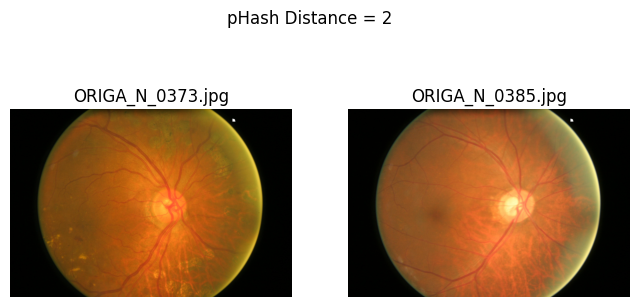

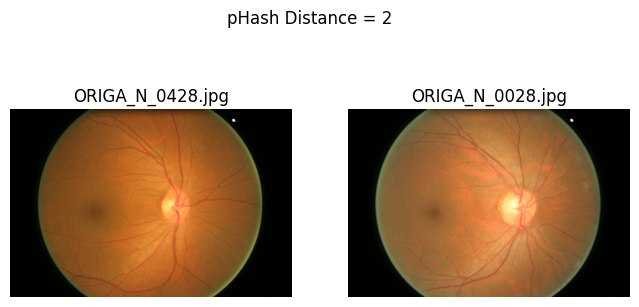

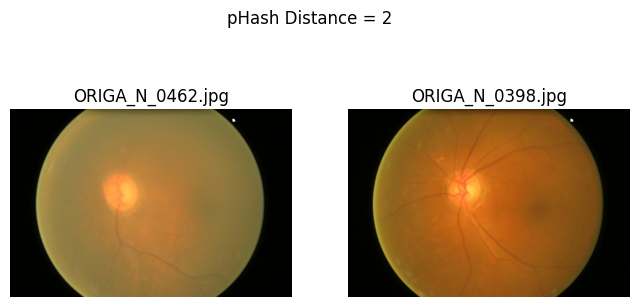

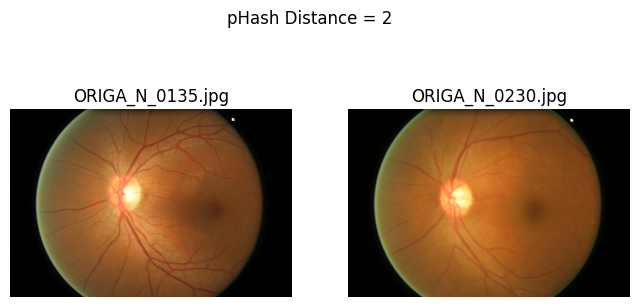

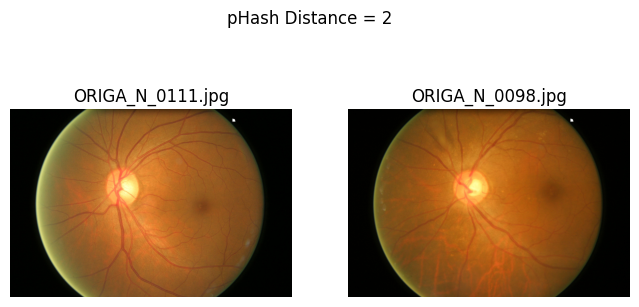

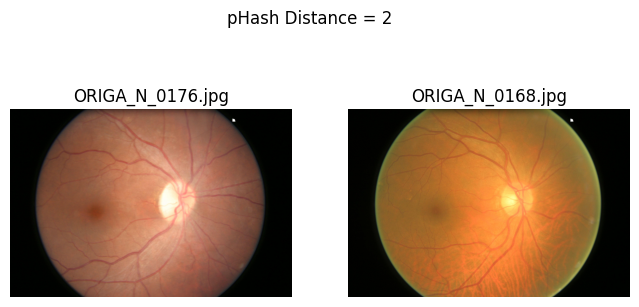

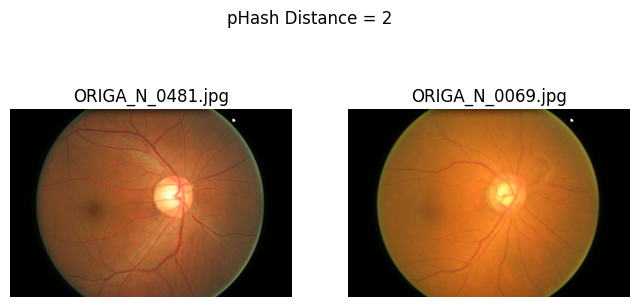

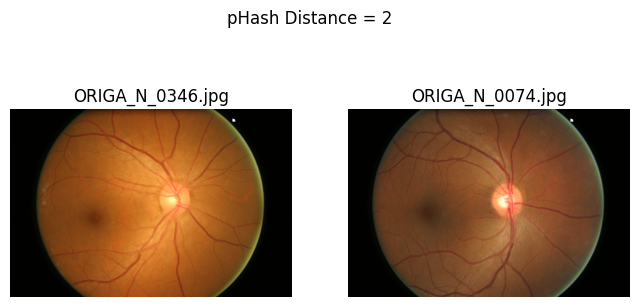

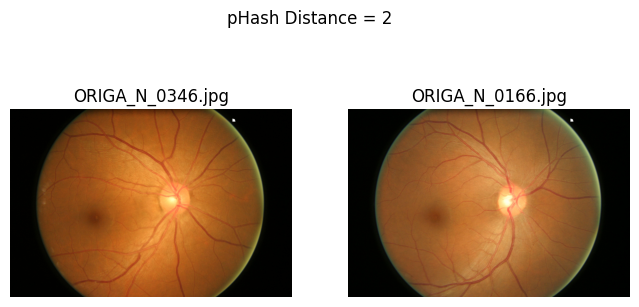

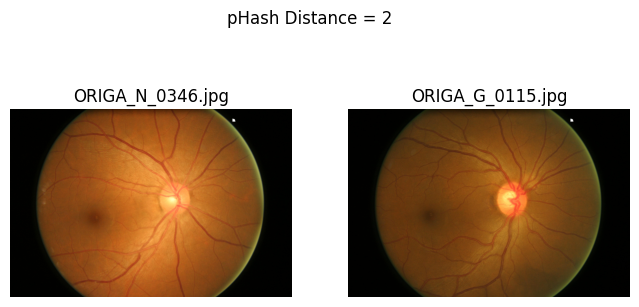

In [25]:
import matplotlib.pyplot as plt
from PIL import Image

# কতগুলো pair দেখতে চাও
NUM_PAIRS = 10

for i, (img1, img2, dist) in enumerate(near_duplicates[:NUM_PAIRS]):

    plt.figure(figsize=(8,4))

    plt.subplot(1,2,1)
    plt.imshow(Image.open(img1))
    plt.title(os.path.basename(img1))
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(Image.open(img2))
    plt.title(os.path.basename(img2))
    plt.axis("off")

    plt.suptitle(f"pHash Distance = {dist}")

    plt.show()

# 📌 Cell 15 : Final Dataset Audit

In [26]:
import os
from PIL import Image

print("=" * 60)
print("FINAL DATASET AUDIT")
print("=" * 60)

normal_dir = os.path.join(WORKING_DIR, "Normal")
glaucoma_dir = os.path.join(WORKING_DIR, "Glaucoma")

normal_files = os.listdir(normal_dir)
glaucoma_files = os.listdir(glaucoma_dir)

print(f"Normal Images   : {len(normal_files)}")
print(f"Glaucoma Images : {len(glaucoma_files)}")
print(f"Total Images    : {len(normal_files) + len(glaucoma_files)}")

print("\n" + "=" * 60)
print("Sample Images")
print("=" * 60)

print("\nFirst 5 Normal Images:")
for f in sorted(normal_files)[:5]:
    print(f)

print("\nFirst 5 Glaucoma Images:")
for f in sorted(glaucoma_files)[:5]:
    print(f)

print("\n" + "=" * 60)
print("Image Size Check")
print("=" * 60)

for cls in ["Normal", "Glaucoma"]:
    folder = os.path.join(WORKING_DIR, cls)

    sample = sorted(os.listdir(folder))[0]
    path = os.path.join(folder, sample)

    img = Image.open(path)

    print(f"{cls}")
    print("Sample :", sample)
    print("Resolution :", img.size)
    print("Mode :", img.mode)
    print("-" * 40)

FINAL DATASET AUDIT
Normal Images   : 791
Glaucoma Images : 564
Total Images    : 1355

Sample Images

First 5 Normal Images:
ACRIMA_N_0001.jpg
ACRIMA_N_0002.jpg
ACRIMA_N_0003.jpg
ACRIMA_N_0004.jpg
ACRIMA_N_0005.jpg

First 5 Glaucoma Images:
ACRIMA_G_0001.jpg
ACRIMA_G_0002.jpg
ACRIMA_G_0003.jpg
ACRIMA_G_0004.jpg
ACRIMA_G_0005.jpg

Image Size Check
Normal
Sample : ACRIMA_N_0001.jpg
Resolution : (349, 349)
Mode : RGB
----------------------------------------
Glaucoma
Sample : ACRIMA_G_0001.jpg
Resolution : (1054, 1054)
Mode : RGB
----------------------------------------
